# WCO Model MobileNetV1 -> alpha = 0.25 -> 128x128
**Output:** contamination + colour
**Inference:** FastAPI server (Keras float32)
**ESP32:** sadece görüntü toplar, inference yok

In [ ]:
# ── 1. Drive mount ────────────────────────────────────────────────
import os
from google.colab import drive

drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/cropped128'
SAVE_PATH = '/content/drive/MyDrive/models/MobileNetV1_a025.keras'

os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

Mounted at /content/drive


In [ ]:
# ── 2. Import ─────────────────────────────────────────────────────
import os, re
import numpy as np
import tensorflow as tf
import keras
from keras import layers, Model
from keras.applications import MobileNet
from sklearn.model_selection import train_test_split

IMG_SIZE   = 128
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

print('TF version:', tf.__version__)

TF version: 2.19.0


In [ ]:
# ── 3. Label parse ────────────────────────────────────────────────
# contamination = min(1, turbidity + particle)
# colour ayrı kalır
def parse_label(filename):
    m = re.match(r't(\d)[_-]p(\d)[_-]c(\d)', filename)
    if not m:
        return None
    t, p, c = int(m.group(1)), int(m.group(2)), int(m.group(3))
    return np.array([t, p, c], dtype=np.float32)

all_files, all_labels = [], []

for fname in sorted(os.listdir(DRIVE_DIR)):
    if not (fname.endswith('.jpg') or fname.endswith('.jpeg')):
        continue

    lbl = parse_label(fname)
    if lbl is None:
        print(f'SKIP: {fname}')
        continue
    all_files.append(os.path.join(DRIVE_DIR, fname))
    all_labels.append(lbl)

all_labels = np.array(all_labels, dtype=np.float32)
print(f'Toplam        : {len(all_files)} görüntü')
print(f'turbidity   : {all_labels[:,0].sum():.0f} pozitif')
print(f'particle    : {all_labels[:,1].sum():.0f} pozitif')
print(f'colour      : {all_labels[:,2].sum():.0f} pozitif')

Toplam        : 296 görüntü
turbidity   : 143 pozitif
particle    : 143 pozitif
colour      : 145 pozitif


In [ ]:
# ── 4. Train / val / test split ───────────────────────────────────
# Stratify: colour (en az varyans)
colour_buckets = all_labels[:, 2].astype(int)

files_train, files_temp, y_train, y_temp = train_test_split(
    all_files, all_labels,
    test_size=0.30, stratify=colour_buckets, random_state=42
)
colour_buckets_temp = y_temp[:, 2].astype(int)
files_val, files_test, y_val, y_test = train_test_split(
    files_temp, y_temp,
    test_size=0.50, stratify=colour_buckets_temp, random_state=42
)

print(f'Train : {len(files_train)}')
print(f'Val   : {len(files_val)}')
print(f'Test  : {len(files_test)}')


Train : 207
Val   : 44
Test  : 45


In [ ]:
# ── 5. tf.data pipeline ───────────────────────────────────────────
augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
], name='augmentation')

def load_train(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0  # [0,1] — uint8 input ile uyumlu
    return img, {
        'turbidity': label[0:1],
        'particle':  label[1:2],
        'colour':    label[2:3],
    }

def load_eval(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0  # [0,1] — uint8 input ile uyumlu
    return img, {
        'turbidity': label[0:1],
        'particle':  label[1:2],
        'colour':    label[2:3],
    }

train_ds = (tf.data.Dataset.from_tensor_slices((files_train, y_train))
            .shuffle(len(files_train), seed=42)
            .map(load_train, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE).prefetch(AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((files_val, y_val))
          .map(load_eval, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE).prefetch(AUTOTUNE))

test_ds = (tf.data.Dataset.from_tensor_slices((files_test, y_test))
           .map(load_eval, num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE).prefetch(AUTOTUNE))

print('Pipeline hazır')

Pipeline hazır


In [ ]:
# ── 6. Model ──────────────────────────────────────────────────────
def build_model():
    backbone = MobileNet(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        alpha=0.25,
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = False

    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomRotation(0.08)(x)
    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out_turb = layers.Dense(1, activation='sigmoid', name='turbidity')(x)
    out_part = layers.Dense(1, activation='sigmoid', name='particle')(x)
    out_col  = layers.Dense(1, activation='sigmoid', name='colour')(x)

    model = Model(inputs=inputs, outputs={
        'turbidity': out_turb,
        'particle':  out_part,
        'colour':    out_col,
    })
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss={
            'turbidity': 'binary_crossentropy',
            'particle':  'binary_crossentropy',
            'colour':    'binary_crossentropy',
        },
        loss_weights={
            'turbidity': 1.0,
            'particle':  1.0,
            'colour':    1.5,
        },
        metrics={
            'turbidity': ['accuracy'],
            'particle':  ['accuracy'],
            'colour':    ['accuracy'],
        }
    )
    return model

model = build_model()
model.summary()


2108140/2108140 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_1       │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_1   │ (None, 128, 128,  │          0 │ random_flip_1[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenet_0.25_128  │ (None, 4, 4, 256) │    218,544 │ random_rotation_… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ mobilenet_0.25_1… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ colour (Dense)      │ (None, 1)         │        129 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ particle (Dense)    │ (None, 1)         │        129 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ turbidity (Dense)   │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 251,827 (983.70 KB)

 Trainable params: 33,283 (130.01 KB)

 Non-trainable params: 218,544 (853.69 KB)

In [ ]:
# ── 7. Eğitim ─────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=7, restore_best_weights=True
    ),
    keras.callbacks.ModelCheckpoint(
        SAVE_PATH, monitor='val_loss', save_best_only=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

print(f'\nEn iyi model kaydedildi: {SAVE_PATH}')

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - colour_accuracy: 0.5749 - colour_loss: 0.7279 - loss: 2.5245 - particle_accuracy: 0.6812 - particle_loss: 0.6362 - turbidity_accuracy: 0.6184 - turbidity_loss: 0.7916 - val_colour_accuracy: 0.7727 - val_colour_loss: 0.4585 - val_loss: 1.3943 - val_particle_accuracy: 0.9545 - val_particle_loss: 0.1925 - val_turbidity_accuracy: 0.8636 - val_turbidity_loss: 0.5173 - learning_rate: 0.0010
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 220ms/step - colour_accuracy: 0.8599 - colour_loss: 0.3820 - loss: 1.4974 - particle_accuracy: 0.9179 - particle_loss: 0.2362 - turbidity_accuracy: 0.6087 - turbidity_loss: 0.6862 - val_colour_accuracy: 0.9545 - val_colour_loss: 0.2589 - val_loss: 1.1049 - val_particle_accuracy: 0.9773 - val_particle_loss: 0.0925 - val_turbidity_accuracy: 0.7500 - val_turbidity_loss: 0.6281 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - colour_accuracy: 0.9034 - colour_loss: 0.2588 - loss: 1.0519 - p

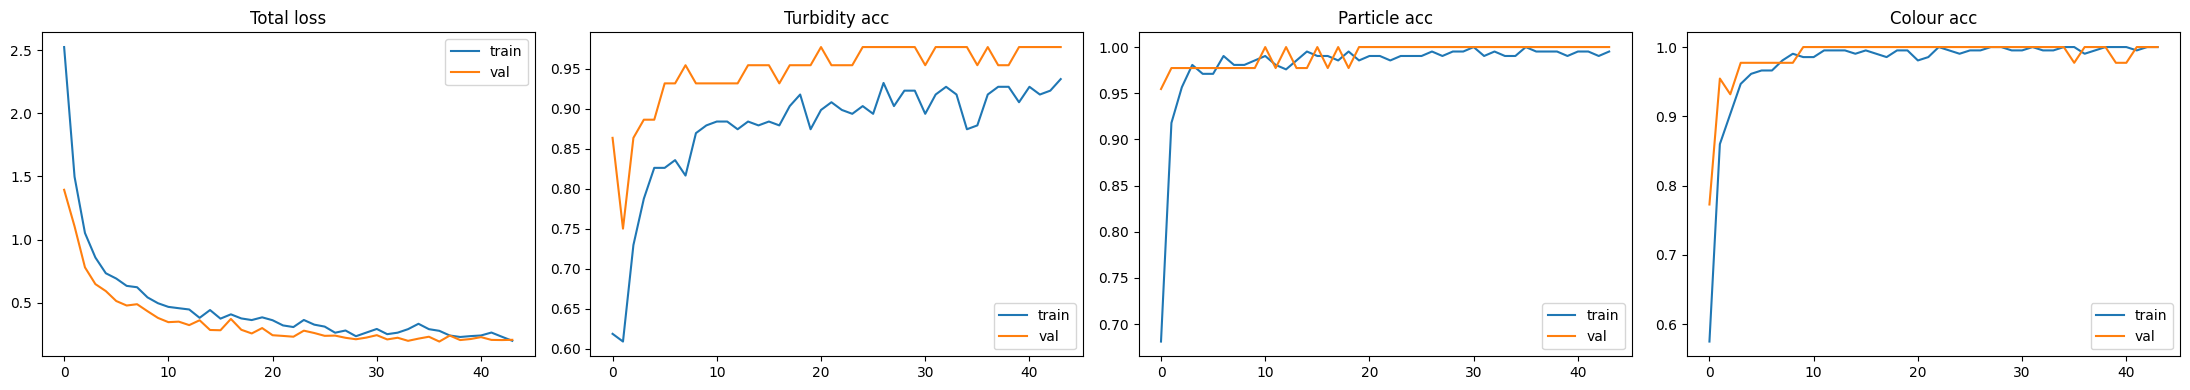

In [ ]:
# ── 8. Training curve ─────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(22, 4))
metrics = [
    ('loss',                'Total loss'),
    ('turbidity_accuracy',  'Turbidity acc'),
    ('particle_accuracy',   'Particle acc'),
    ('colour_accuracy',     'Colour acc'),
]
for ax, (metric, title) in zip(axes, metrics):
    ax.plot(history.history[metric], label='train')
    ax.plot(history.history[f'val_{metric}'], label='val')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120)
plt.show()


In [ ]:
# ── 9. Test seti değerlendirme ────────────────────────────────────
best_model = tf.keras.models.load_model(SAVE_PATH)

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

y_true = {'turbidity': [], 'particle': [], 'colour': []}
y_pred = {'turbidity': [], 'particle': [], 'colour': []}
scores = {'turbidity': [], 'particle': [], 'colour': []}

for imgs, labels in test_ds:
    preds = best_model.predict(imgs, verbose=0)
    for key in ['turbidity', 'particle', 'colour']:
        y_true[key].extend(labels[key].numpy().flatten())
        scores[key].extend(preds[key].flatten())
        y_pred[key].extend((preds[key] > 0.5).flatten().astype(int))

for key in ['turbidity', 'particle', 'colour']:
    acc = accuracy_score(y_true[key], y_pred[key])
    f1  = f1_score(y_true[key], y_pred[key], zero_division=0)
    cm  = confusion_matrix(y_true[key], y_pred[key])
    sc  = scores[key]
    print(f'\n── {key} ──')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 Score : {f1:.4f}')
    print(f'  Score min/max/mean: {min(sc):.3f} / {max(sc):.3f} / {np.mean(sc):.3f}')
    print(f'  Confusion matrix:\n{cm}')



── turbidity ──
  Accuracy : 0.8667
  F1 Score : 0.8500
  Score min/max/mean: 0.003 / 0.997 / 0.453
  Confusion matrix:
[[22  2]
 [ 4 17]]

── particle ──
  Accuracy : 1.0000
  F1 Score : 1.0000
  Score min/max/mean: 0.001 / 1.000 / 0.471
  Confusion matrix:
[[24  0]
 [ 0 21]]

── colour ──
  Accuracy : 1.0000
  F1 Score : 1.0000
  Score min/max/mean: 0.000 / 1.000 / 0.491
  Confusion matrix:
[[23  0]
 [ 0 22]]


In [ ]:
# ── 10. Optimal threshold ─────────────────────────────────────────
for key in ['turbidity', 'particle', 'colour']:
    best_t, best_f1 = 0.5, 0
    for thresh in np.arange(0.05, 0.95, 0.05):
        yp = [1 if s > thresh else 0 for s in scores[key]]
        f1 = f1_score(y_true[key], yp, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t  = thresh
    yp_best = [1 if s > best_t else 0 for s in scores[key]]
    acc = accuracy_score(y_true[key], yp_best)
    print(f'{key}: best_threshold={best_t:.2f}  acc={acc:.3f}  f1={best_f1:.3f}')


turbidity: best_threshold=0.15  acc=0.889  f1=0.894
particle: best_threshold=0.15  acc=1.000  f1=1.000
colour: best_threshold=0.20  acc=1.000  f1=1.000


In [ ]:
# from PIL import Image
# import numpy as np
# import glob, os

# best_model = tf.keras.models.load_model(SAVE_PATH)

# images = sorted(glob.glob('/content/test_images/*.jpg') + glob.glob('/content/test_images/*.jpeg'))

# if not images:
#     print('Görüntü bulunamadı — /content/*.jpg formatında kaydet')
# else:
#     print(f"{'Dosya':<30} {'Contamination':>15} {'Colour':>10} {'Karar'}")
#     print('-' * 70)
#     for path in images:
#         img = Image.open(path).convert('RGB').resize((192, 192))
#         arr = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, axis=0)
#         preds = best_model.predict(arr, verbose=0)
#         cont  = float(preds[0][0][0])
#         col   = float(preds[1][0][0])
#         karar = []
#         if cont > 0.25: karar.append('KİRLİ')
#         if col  > 0.05: karar.append('RENKLİ')
#         if not karar:   karar.append('TEMİZ')
#         fname = os.path.basename(path)
#         print(f'{fname:<30} {cont:>15.4f} {col:>10.4f}  {", ".join(karar)}')

In [ ]:
# ── TFLite INT8 dönüşümü ──────────────────────────────────────────
import tensorflow as tf

# En iyi modeli Drive'dan yükle
best_model = tf.keras.models.load_model(SAVE_PATH)

TFLITE_PATH = '/content/drive/MyDrive/models/MobileNetV1_a025.tflite'

def representative_dataset():
    for imgs, _ in train_ds:
        yield [imgs]

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.uint8
converter.inference_output_type = tf.float32  # çıkış float32 — hassasiyet kaybı önlenir

tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

print(f'Model boyutu: {len(tflite_model)/1024:.1f} KB')
print(f'Kaydedildi: {TFLITE_PATH}')

# Tensor sırasını kontrol et
interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
interpreter.allocate_tensors()
output_details = interpreter.get_output_details()
for i, o in enumerate(output_details):
    print(f'[{i}] {o["name"]}  dtype={o["dtype"]}')

Saved artifact at '/tmp/tmpc9w9wxli'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_6')
Output Type:
  List[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)]
Captures:
  134144806090896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134144744101392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134144744100816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134144744099472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134144744105040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134144744098512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134144744096400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134144744102928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134144744104080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134144744096784: Te

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model boyutu: 336.3 KB
Kaydedildi: /content/drive/MyDrive/models/MobileNetV1_a025.tflite
[0] StatefulPartitionedCall_1:1  dtype=<class 'numpy.uint8'>
[1] StatefulPartitionedCall_1:0  dtype=<class 'numpy.uint8'>


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
# import numpy as np
# from PIL import Image
# import tensorflow as tf
# best_model = tf.keras.models.load_model(SAVE_PATH)
# # JPEG'i aç ama önce uint8 array'e çevir, sonra float yap
# img = Image.open("/content/con8633co1719.jpeg").convert("RGB")
# arr_uint8 = np.array(img, dtype=np.uint8)
# # uint8 direkt — ESP32'nin yaptığı gibi
# arr_float = np.expand_dims(arr_uint8.astype(np.float32) / 255.0, axis=0)
# preds = best_model.predict(arr_float, verbose=0)
# print(f"contamination: {preds[0][0][0]:.4f}")
# print(f"colour:        {preds[1][0][0]:.4f}")
# # Ayrıca TFLite ile de test et
# interpreter = tf.lite.Interpreter(model_path="/content/drive/MyDrive/wco_model_v7_int8.tflite")
# interpreter.allocate_tensors()
# input_details = interpreter.get_input_details()
# output_details = interpreter.get_output_details()
# img_uint8 = np.expand_dims(arr_uint8, axis=0)
# interpreter.set_tensor(input_details[0]['index'], img_uint8)
# interpreter.invoke()
# raw0 = interpreter.get_tensor(output_details[0]['index'])[0][0]
# raw1 = interpreter.get_tensor(output_details[1]['index'])[0][0]
# scale = output_details[0]['quantization'][0]
# print(f"\nTFLite [0]: {int(raw0) * scale:.4f}")
# print(f"TFLite [1]: {int(raw1) * scale:.4f}")

In [ ]:
!xxd -i /content/drive/MyDrive/models/MobileNetV1_a025.tflite > /content/drive/MyDrive/models/MobileNetV1_a025.cpp

In [ ]:
# with open('/content/drive/MyDrive/models/MobileNetV1_a025.cpp', 'r') as f:
#     content = f.read()

# content = (
#       '#include "MobileNetV1_a025.h"\n\n'
#       '#ifdef __has_attribute\n#define HAVE_ATTRIBUTE(x) __has_attribute(x)\n'
#       '#else\n#define HAVE_ATTRIBUTE(x) 0\n#endif\n'
#       '#if HAVE_ATTRIBUTE(aligned) || (defined(__GNUC__) && !defined(__clang__))\n'
#       '#define DATA_ALIGN_ATTRIBUTE __attribute__((aligned(4)))\n'
#       '#else\n#define DATA_ALIGN_ATTRIBUTE\n#endif\n\n'
#       + content
#       .replace('unsigned char wco_model_v2_int8_tflite[]',
#                'const unsigned char g_wco_model_v2_data[] DATA_ALIGN_ATTRIBUTE')
#       .replace('unsigned int _content_drive_MyDrive_wco_model_v7_int8_tflite_len',
#                'const int g_wco_model_v2_data_len')
#   )

# with open('/content/wco_model_data.cpp', 'w') as f:
#       f.write(content)

# print('Hazır:', '/content/wco_model_data.cpp')